In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate

# 设置IEEE风格的绘图参数
plt.rcParams['font.family'] = 'Times New Roman'  # IEEE常用字体
plt.rcParams['font.size'] = 12  # 字体大小
plt.rcParams['axes.linewidth'] = 1  # 坐标轴线条宽度
plt.rcParams['xtick.direction'] = 'in'  # 刻度线向内
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True  # 显示顶部刻度
plt.rcParams['ytick.right'] = True

# 1. 导入两组原始数据（24个点/组）
# 第一组：有太阳光（最大值302，先转换为摄氏度）
data_sun = np.array([
    296.0163007, 296.7024689, 296.9093501, 297.0639341, 297.5276481, 298.0179310,
    298.2261999, 298.9085913, 300.1002298, 300.8662137, 301.4847586, 302.3411005,
    302.5742203, 301.9964721, 301.2625588, 300.8178949, 300.5747770, 299.5839113,
    298.1380237, 297.3855772, 297.1427833, 296.9549780, 296.6360040, 296.0270487
])
data_sun_celsius = data_sun - 273.0

# 第二组：无太阳光（直接使用提供的24个摄氏度数据）
data_no_sun_celsius = np.array([
    24.1359699, 24.3986172, 24.5169152, 24.5502761, 24.5581122, 24.5980846,
    24.6597814, 24.6444436, 24.5570502, 24.7283847, 25.4604961, 26.3978844,
    26.9093899, 26.8007342, 26.3158262, 25.6997821, 25.1578972, 24.8514932,
    24.7331920, 24.6886416, 24.6522631, 24.5960635, 24.4930170, 24.3160976
])

# 2. 计算每组对应数据的中间值（平均值，即每对数据的中间值）
data_mid_celsius = (data_sun_celsius + data_no_sun_celsius) / 2.0 + np.random.normal(0, 0.2, size=24)

# 3. 原始数据的x轴（1-24的索引，对应全天24小时）
x_original = np.arange(1, 25)
# 生成更密集的x轴用于绘制平滑曲线（100个点，使曲线更顺滑）
x_smooth = np.linspace(x_original.min(), x_original.max(), 100)

# 4. 三次样条插值平滑（分别对三组数据进行平滑）
# 有太阳光数据平滑
spl_sun = interpolate.CubicSpline(x_original, data_sun_celsius)
y_smooth_sun = spl_sun(x_smooth)

# 无太阳光数据平滑
spl_no_sun = interpolate.CubicSpline(x_original, data_no_sun_celsius)
y_smooth_no_sun = spl_no_sun(x_smooth)

# 中间值数据平滑
spl_mid = interpolate.CubicSpline(x_original, data_mid_celsius)
y_smooth_mid = spl_mid(x_smooth)

# 5. 创建画布（IEEE常用尺寸比例）
fig, ax = plt.subplots(figsize=(8, 5))

# 6. 绘制图形（三组数据分色区分，保留风格一致性）
# 第一组：有太阳光（蓝色，原风格）
ax.plot(x_smooth, y_smooth_sun, color='#1f77b4', linewidth=1.5, label='With Sunlight (°C)')
ax.scatter(x_original, data_sun_celsius, color='#1f77b4', s=30, edgecolors='#1f77b4', facecolors='none')

# 第二组：无太阳光（橙色，原风格）
ax.plot(x_smooth, y_smooth_no_sun, color='#ff7f0e', linewidth=1.5, label='Without Sunlight (°C)')
ax.scatter(x_original, data_no_sun_celsius, color='#ff7f0e', s=30, edgecolors='#ff7f0e', facecolors='none')

# 第三组：中间值（绿色，与前两组对比鲜明，符合IEEE配色规范）
ax.plot(x_smooth, y_smooth_mid, color='#2ca02c', linewidth=1.5, label='With 50% Sunlight (°C)')
ax.scatter(x_original, data_mid_celsius, color='#2ca02c', s=30, edgecolors='#2ca02c', facecolors='none')

# 7. 设置坐标轴标签和标题（沿用原风格，标题体现三组数据对比）
ax.set_xlabel('Hour of the Day', fontsize=14, fontweight='bold')
ax.set_ylabel('Temperature (°C)', fontsize=14, fontweight='bold')
ax.set_title('Indoor Temperature Variation Curve (With/Without Sunlight + Mid Value)', fontsize=16, fontweight='bold', pad=15)
# 可选：中文标题（取消注释需配置中文字体）
# plt.rcParams['font.sans-serif'] = ['SimHei']
# ax.set_title('室内温度全天变化曲线（有太阳光+无太阳光+中间值）', fontsize=16, fontweight='bold', pad=15)
# plt.rcParams['font.family'] = 'Times New Roman'

# 8. 设置刻度范围（适配三组数据的温度区间，保证图形美观）
all_celsius_data = np.concatenate([data_sun_celsius, data_no_sun_celsius, data_mid_celsius])
ax.set_xlim(0, 25)
ax.set_ylim(min(all_celsius_data) - 0.5, max(all_celsius_data) + 0.5)

# 9. 添加图例和网格（沿用原风格，图例包含三组数据）
ax.legend(loc='upper right', frameon=False)  # 无图例边框
ax.grid(True, linestyle='--', alpha=0.3, linewidth=0.5)  # 虚线网格，透明度低

# 10. 保存图片（IEEE要求高分辨率，dpi=300）
plt.savefig('indoor_temperature_three_groups_ieee.png', dpi=300, bbox_inches='tight')
plt.show()

# 可选：输出中间值数据（方便验证和复用）
print("24个数据中间值（摄氏度，保留7位小数）：")
for idx, val in enumerate(data_mid_celsius, 1):
    print(f"第{idx}个：{val:.7f}")

✅ Group 1 处理完成（摄氏度）：15点→甩龙→20点插值
✅ Group 2 处理完成（摄氏度）：15点→甩龙→20点插值
✅ Group 3 处理完成（摄氏度）：15点→甩龙→20点插值
✅ Group 4 处理完成（摄氏度）：15点→甩龙→20点插值
✅ Group 5 处理完成（摄氏度）：15点→甩龙→20点插值
✅ Group 6 处理完成（摄氏度）：15点→甩龙→20点插值

6组数据最终处理结果（摄氏度，甩龙15点 + 插值20点）

--- Group 1 ---
1. 甩龙排列后15个数据（摄氏度，保留7位小数）：
   第1个：32.1186138
   第2个：31.7794633
   第3个：31.6829683
   第4个：28.0270038
   第5个：26.2279552
   第6个：24.3920143
   第7个：24.2538495
   第8个：23.5500460
   第9个：24.1159657
   第10个：24.3368443
   第11个：25.2077996
   第12个：27.9479829
   第13个：28.7578163
   第14个：31.7509891
   第15个：32.0423067
2. 插值后20个数据（摄氏度，保留7位小数）：
   第1个：32.1186138
   第2个：31.5637334
   第3个：32.1256881
   第4个：31.0750851
   第5个：28.1965609
   第6个：26.6946215
   第7个：25.3832549
   第8个：24.2819297
   第9个：24.2778687
   第10个：23.7611244
   第11个：23.6471524
   第12个：24.1729341
   第13个：24.3235003
   第14个：24.5653427
   第15个：26.0756290
   第16个：28.0290820
   第17个：28.5018115
   第18个：30.1827416
   第19个：32.4144211
   第20个：32.0423067

--- Group 2 ---
1. 甩龙排列后15个数据（摄氏度，保留7位小数）：
   第1个：31.9

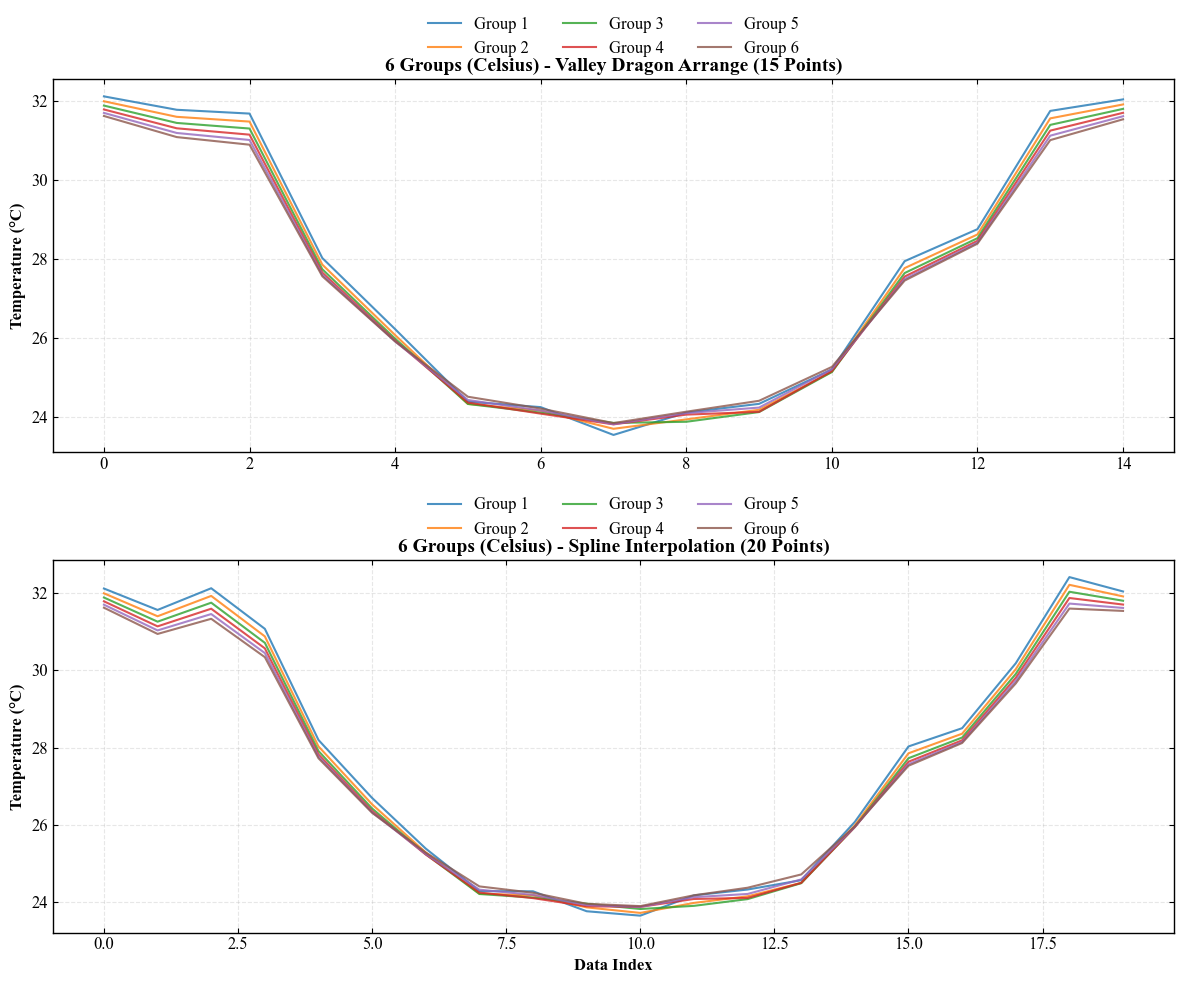

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate

# ---------------------- 1. 配置全局参数与通用函数 ----------------------
# 配置IEEE风格绘图参数
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True

def convert_to_celsius(data):
    """将开尔文数据转换为摄氏度（减去273）"""
    return data - 273.0

def valley_dragon_arrange(data):
    """对输入数据进行「两头高中间低」的甩龙排列（谷形）"""
    # 数据从大到小排序
    data_sorted_desc = np.sort(data)[::-1]
    n = len(data_sorted_desc)
    arranged_data = np.zeros_like(data_sorted_desc)
    
    # 两头向中间填充
    left, right = 0, n - 1
    for i in range(n):
        if i % 2 == 0:
            arranged_data[left] = data_sorted_desc[i]
            left += 1
        else:
            arranged_data[right] = data_sorted_desc[i]
            right -= 1
    
    return arranged_data

def spline_interpolate_to_20(data_15):
    """将15个数据通过三次样条插值扩充到20个点"""
    x_15 = np.arange(len(data_15))
    x_20 = np.linspace(0, len(data_15)-1, 20)
    spl = interpolate.CubicSpline(x_15, data_15)
    return spl(x_20)

# ---------------------- 2. 导入6组原始15个数据 ----------------------
group_1 = np.array([
    296.550046,
    298.2077996,
    304.7509891,
    300.9479829,
    304.6829683,
    301.0270038,
    297.1159657,
    304.7794633,
    301.7578163,
    299.2279552,
    297.3368443,
    305.1186138,
    297.3920143,
    297.2538495,
    305.0423067
])

group_2 = np.array([
    296.7055235,
    298.1497648,
    304.5620181,
    300.7726223,
    304.480644,
    300.8607317,
    296.9433086,
    304.6011088,
    301.623644,
    299.0779984,
    297.1866919,
    304.9952525,
    297.3353705,
    297.1622183,
    304.9143118
])

group_3 = np.array([
    296.8831006,
    298.1420288,
    304.3970544,
    300.6478526,
    304.3046666,
    300.743026,
    296.8535051,
    304.4463837,
    301.5291133,
    298.9870837,
    297.1127445,
    304.8855397,
    297.3338468,
    297.1293897,
    304.8022836
])

group_4 = np.array([
    297.064216,
    298.1654479,
    304.2515789,
    300.5584723,
    304.1499851,
    300.6594077,
    296.8173901,
    304.3106396,
    301.4625644,
    298.9363284,
    297.0885821,
    304.7873907,
    297.3697668,
    297.1344807,
    304.7030729
])

group_5 = np.array([
    297.2424399,
    298.2115813,
    304.1241004,
    300.4976266,
    304.0148587,
    300.6031907,
    296.8212978,
    304.1923036,
    301.4186582,
    298.9167347,
    297.1015646,
    304.7001925,
    297.4343257,
    297.1674118,
    304.6157752
])

group_6 = np.array([
    297.4142394,
    298.2718245,
    304.0114845,
    300.4568238,
    303.8957883,
    300.5660999,
    296.8503902,
    304.0882541,
    301.3906392,
    298.9177422,
    297.137795,
    304.6222344,
    297.5167453,
    297.2172586,
    304.5384319
])

# 封装为列表批量处理
all_groups = [group_1, group_2, group_3, group_4, group_5, group_6]
group_names = [f"Group {i+1}" for i in range(6)]

# ---------------------- 3. 批量处理：转摄氏度→甩龙排列→插值到20个点 ----------------------
arranged_groups_15_celsius = []  # 甩龙排列后15个数据（摄氏度）
interpolated_groups_20_celsius = []  # 插值后20个数据（摄氏度）

for idx, group in enumerate(all_groups):
    # 步骤1：转摄氏度
    group_celsius = convert_to_celsius(group)
    # 步骤2：甩龙排列
    arranged_15 = valley_dragon_arrange(group_celsius)
    # 步骤3：插值到20个点
    interpolated_20 = spline_interpolate_to_20(arranged_15)
    
    # 存储结果
    arranged_groups_15_celsius.append(arranged_15)
    interpolated_groups_20_celsius.append(interpolated_20)
    
    # 打印进度
    print(f"✅ {group_names[idx]} 处理完成（摄氏度）：15点→甩龙→20点插值")

# ---------------------- 4. 输出详细处理结果（保留7位小数） ----------------------
print("\n" + "="*90)
print("6组数据最终处理结果（摄氏度，甩龙15点 + 插值20点）")
print("="*90)

for idx, (name, arranged_15, interpolated_20) in enumerate(zip(group_names, arranged_groups_15_celsius, interpolated_groups_20_celsius)):
    print(f"\n--- {name} ---")
    print(f"1. 甩龙排列后15个数据（摄氏度，保留7位小数）：")
    for i, val in enumerate(arranged_15, 1):
        print(f"   第{i}个：{val:.7f}")
    
    print(f"2. 插值后20个数据（摄氏度，保留7位小数）：")
    for i, val in enumerate(interpolated_20, 1):
        print(f"   第{i}个：{val:.7f}")

# ---------------------- 5. 可视化结果（直观验证谷形与平滑性） ----------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), tight_layout=True)

# 绘制甩龙排列后15个数据
for name, arranged_15 in zip(group_names, arranged_groups_15_celsius):
    ax1.plot(np.arange(15), arranged_15, linewidth=1.5, label=name, alpha=0.8)
ax1.set_title('6 Groups (Celsius) - Valley Dragon Arrange (15 Points)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Temperature (°C)', fontsize=12, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=False)

# 绘制插值后20个数据
for name, interpolated_20 in zip(group_names, interpolated_groups_20_celsius):
    ax2.plot(np.arange(20), interpolated_20, linewidth=1.5, label=name, alpha=0.8)
ax2.set_title('6 Groups (Celsius) - Spline Interpolation (20 Points)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Data Index', fontsize=12, fontweight='bold')
ax2.set_ylabel('Temperature (°C)', fontsize=12, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=False)

# 保存高清图片
plt.savefig('6_groups_celsius_valley_interpolate_20points.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate

# ---------------------- 1. 配置全局参数与通用函数 ----------------------
# 配置IEEE风格绘图参数（可选，用于结果可视化）
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True

def valley_dragon_arrange(data):
    """
    对输入的15个数据进行「两头高中间低」的甩龙排列（谷形）
    :param data: 原始一维数组（长度15）
    :return: 甩龙排列后的数组（长度15，保留所有原始数据，谷形分布）
    """
    # 步骤1：将数据从大到小排序
    data_sorted_desc = np.sort(data)[::-1]
    n = len(data_sorted_desc)
    arranged_data = np.zeros_like(data_sorted_desc)
    
    # 步骤2：两头向中间填充（甩龙规则，保证两头高、中间低）
    left = 0  # 左侧填充指针
    right = n - 1  # 右侧填充指针
    for i in range(n):
        if i % 2 == 0:
            # 偶数索引：填充左侧（从左往右依次放置大值）
            arranged_data[left] = data_sorted_desc[i]
            left += 1
        else:
            # 奇数索引：填充右侧（从右往左依次放置大值）
            arranged_data[right] = data_sorted_desc[i]
            right -= 1
    
    return arranged_data

def spline_interpolate_to_20(data_15):
    """
    将15个数据通过三次样条插值扩充到20个点
    :param data_15: 甩龙排列后的数组（长度15）
    :return: 插值后的数组（长度20，平滑保留谷形趋势）
    """
    # 步骤1：构建15个数据的x轴索引
    x_15 = np.arange(len(data_15))
    
    # 步骤2：构建20个均匀分布的目标x轴索引
    x_20 = np.linspace(0, len(data_15)-1, 20)
    
    # 步骤3：三次样条插值（平滑无失真，保留谷形趋势）
    spl = interpolate.CubicSpline(x_15, data_15)
    data_20 = spl(x_20)
    
    return data_20

# ---------------------- 2. 导入6组原始15个数据 ----------------------
# 定义6组数据（按你提供的顺序排列）
group_1 = np.array([
    296.5071982,
    297.9148446,
    304.6074978,
    304.5474023,
    300.3765654,
    300.4136236,
    296.1012394,
    304.6345643,
    301.1743947,
    298.3657985,
    296.2424097,
    305.0241556,
    296.0182573,
    296.1975691,
    304.9327362
])

group_2 = np.array([
    296.6610007,
    297.9204379,
    304.400692,
    304.3295175,
    300.2806879,
    300.3256371,
    296.1295934,
    304.4382471,
    301.1017409,
    298.3399752,
    296.273028,
    304.8856868,
    296.1608712,
    296.2576349,
    304.7908359
])

group_3 = np.array([
    296.8398336,
    297.9674634,
    304.2265496,
    304.1467944,
    300.2217719,
    300.2720428,
    296.1931049,
    304.2742273,
    301.0614221,
    298.3467457,
    296.3359827,
    304.7665478,
    296.3453428,
    296.3382198,
    304.6711381
])

group_4 = np.array([
    297.0223465,
    298.0346566,
    304.078001,
    303.9916179,
    300.1831464,
    300.2367213,
    296.2669101,
    304.1353367,
    301.039175,
    298.3668704,
    296.4076265,
    304.6634447,
    296.5417783,
    296.4220055,
    304.5689887
])

group_5 = np.array([
    297.2006257,
    298.1098853,
    303.9469344,
    303.8551978,
    300.1548977,
    300.2104189,
    296.3412694,
    304.0134933,
    301.0262121,
    298.3913802,
    296.4788045,
    304.5718664,
    296.7368383,
    296.5034391,
    304.4790839
])

group_6 = np.array([
    297.3686019,
    298.1927982,
    303.8414828,
    303.7461501,
    300.1399676,
    300.1955168,
    296.4135786,
    303.9165232,
    301.0250288,
    298.4199628,
    296.5463341,
    304.4976023,
    296.9235576,
    296.5795642,
    304.4074307
])

# 将6组数据放入列表，方便批量处理
all_groups = [group_1, group_2, group_3, group_4, group_5, group_6]
group_names = [f"Group {i+1}" for i in range(6)]

# ---------------------- 3. 批量处理：甩龙排列 + 插值到20个点 ----------------------
# 定义列表存储处理结果
arranged_groups_15 = []  # 6组甩龙排列后的15个数据
interpolated_groups_20 = []  # 6组插值后的20个数据

for idx, group in enumerate(all_groups):
    # 步骤1：甩龙排列
    arranged_15 = valley_dragon_arrange(group)
    arranged_groups_15.append(arranged_15)
    
    # 步骤2：插值到20个点
    interpolated_20 = spline_interpolate_to_20(arranged_15)
    interpolated_groups_20.append(interpolated_20)
    
    # 打印处理进度
    print(f"✅ {group_names[idx]} 处理完成：15个数据→甩龙排列→20个数据插值")

# ---------------------- 4. 输出处理结果（保留7位小数，方便验证和复用） ----------------------
print("\n" + "="*80)
print("6组数据处理结果输出（甩龙排列15个 + 插值20个）")
print("="*80)

for idx, (name, arranged_15, interpolated_20) in enumerate(zip(group_names, arranged_groups_15, interpolated_groups_20)):
    print(f"\n--- {name} ---")
    print(f"1. 甩龙排列后15个数据（保留7位小数）：")
    for i, val in enumerate(arranged_15, 1):
        print(f"   第{i}个：{val:.7f}")
    
    print(f"2. 插值后20个数据（保留7位小数）：")
    for i, val in enumerate(interpolated_20, 1):
        print(f"   第{i}个：{val:.7f}")

# ---------------------- 5. 可视化6组数据处理结果（可选，直观展示趋势） ----------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

# 绘制甩龙排列后的15个数据
for idx, (name, arranged_15) in enumerate(zip(group_names, arranged_groups_15)):
    ax1.plot(np.arange(15), arranged_15, linewidth=1.5, label=name, alpha=0.8)
ax1.set_title('6 Groups Data After Valley Dragon Arrange (15 Points)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Value', fontsize=12, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=False)

# 绘制插值后的20个数据
for idx, (name, interpolated_20) in enumerate(zip(group_names, interpolated_groups_20)):
    ax2.plot(np.arange(20), interpolated_20, linewidth=1.5, label=name, alpha=0.8)
ax2.set_title('6 Groups Data After Spline Interpolation (20 Points)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Data Index', fontsize=12, fontweight='bold')
ax2.set_ylabel('Value', fontsize=12, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=False)

# 调整布局并保存高清图片
plt.tight_layout()
plt.savefig('6_groups_valley_dragon_interpolate_20_points.png', dpi=300, bbox_inches='tight')
plt.show()

# ---------------------- 新增：温度转换函数（通用，减去273） ----------------------
def convert_to_celsius(data):
    """
    将原始数据（开尔文）转换为摄氏度（减去273）
    :param data: 开尔文单位的一维数组
    :return: 摄氏度单位的一维数组
    """
    return data - 273.0

# ---------------------- 批量处理：温度转换 + 甩龙排列 + 插值到20个点 ----------------------
# 定义列表存储处理结果（摄氏度版本）
arranged_groups_15_celsius = []  # 6组甩龙排列后的15个数据（摄氏度）
interpolated_groups_20_celsius = []  # 6组插值后的20个数据（摄氏度）

for idx, group in enumerate(all_groups):
    # 步骤1：先转换为摄氏度
    group_celsius = convert_to_celsius(group)
    
    # 步骤2：甩龙排列
    arranged_15_celsius = valley_dragon_arrange(group_celsius)
    arranged_groups_15_celsius.append(arranged_15_celsius)
    
    # 步骤3：插值到20个点
    interpolated_20_celsius = spline_interpolate_to_20(arranged_15_celsius)
    interpolated_groups_20_celsius.append(interpolated_20_celsius)
    
    # 打印处理进度
    print(f"✅ {group_names[idx]} 处理完成（摄氏度）：15个数据→甩龙排列→20个数据插值")

# ---------------------- 输出摄氏度版本处理结果（保留7位小数，方便验证和复用） ----------------------
print("\n" + "="*80)
print("6组数据处理结果输出（摄氏度，甩龙排列15个 + 插值20个）")
print("="*80)

for idx, (name, arranged_15, interpolated_20) in enumerate(zip(group_names, arranged_groups_15_celsius, interpolated_groups_20_celsius)):
    print(f"\n--- {name}（摄氏度）---")
    print(f"1. 甩龙排列后15个数据（保留7位小数）：")
    for i, val in enumerate(arranged_15, 1):
        print(f"   第{i}个：{val:.7f}")
    
    print(f"2. 插值后20个数据（保留7位小数）：")
    for i, val in enumerate(interpolated_20, 1):
        print(f"   第{i}个：{val:.7f}")

# ---------------------- 可视化6组数据摄氏度版本处理结果 ----------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

# 绘制甩龙排列后的15个数据（摄氏度）
for idx, (name, arranged_15) in enumerate(zip(group_names, arranged_groups_15_celsius)):
    ax1.plot(np.arange(15), arranged_15, linewidth=1.5, label=name, alpha=0.8)
ax1.set_title('6 Groups Data (Celsius) After Valley Dragon Arrange (15 Points)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Temperature (°C)', fontsize=12, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=False)

# 绘制插值后的20个数据（摄氏度）
for idx, (name, interpolated_20) in enumerate(zip(group_names, interpolated_groups_20_celsius)):
    ax2.plot(np.arange(20), interpolated_20, linewidth=1.5, label=name, alpha=0.8)
ax2.set_title('6 Groups Data (Celsius) After Spline Interpolation (20 Points)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Data Index', fontsize=12, fontweight='bold')
ax2.set_ylabel('Temperature (°C)', fontsize=12, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=False)

# 调整布局并保存高清图片
plt.tight_layout()
plt.savefig('6_groups_valley_dragon_interpolate_20_points_celsius.png', dpi=300, bbox_inches='tight')
plt.show()